# Домашнє завдання 13. Порівняння NLP preprocessing на корпусі movie_reviews
Дата заняття: 30.06.2026 (вт)
Модуль: Модуль 6. Обробка природної мови

#### Мета
Порівняти, як різні варіанти preprocessing змінюють текстові дані, частотний словник і найпомітніші слова в позитивних та негативних відгуках з корпусу movie_reviews.

#### Завдання
Створити notebook homework_13_movie_reviews_preprocessing.ipynb.

## Порівняння preprocessing-підходів на відгуках про фільми

### Завдання
1. Завантажте корпус movie_reviews з nltk.corpus.
2. Виберіть однакову кількість позитивних і негативних відгуків, наприклад 100 pos і 100 neg.
3. Створіть DataFrame зі стовпчиками:
fileid	category	text
...	pos / neg	...
4. Реалізуйте 3 варіанти preprocessing:
    * basic: нижній регістр, видалення зайвих символів, токенізація;
    * no_stopwords: basic + видалення англійських stop words і токенів коротших за 3 символи;
    * lemmatized: no_stopwords + лемматизація через WordNetLemmatizer.
5. Для кожного варіанту preprocessing порахуйте:
    * загальну кількість токенів;
    * кількість унікальних токенів;
    * top-10 найчастіших слів для всього вибраного корпусу.
6. Зберіть порівняльну таблицю:

| preprocessing | total_tokens | unique_tokens |	top_3_words |
|:---|:---|:---|:---|
|basic|	...|	...|	...|
|no_stopwords|	...|	...	|...|
|lemmatized|	...|	...|	...|
7. Для варіанту lemmatized окремо порахуйте top-10 слів для позитивних і негативних відгуків.
8. Збережіть цю таблицю в CSV-файл movie_review_top_words.csv зі стовпчиками:

| category | word |	frequency |
|:---|:---|:---|
|pos	| ...  |	...|
|neg	| ...  | ... |
9. Побудуйте горизонтальну bar chart для top-10 слів:
або окремо для pos і neg;
або на одному графіку з двома підграфіками.
10. Збережіть графік як movie_review_top_words.png.
11. Напишіть короткий висновок:
    * як змінилася кількість токенів після видалення stop words;
    * як лемматизація вплинула на унікальні слова;
    * які слова найпомітніші в позитивних і негативних відгуках;
    * чому частотний аналіз ще не є повноцінною sentiment-моделлю.


##### Що здати
    
    Файл homework_13_movie_reviews_preprocessing.ipynb.

In [16]:
import nltk
from nltk.corpus import movie_reviews

nltk.download("movie_reviews")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Анютка\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Анютка\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Анютка\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Анютка\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Анютка\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
pos_ids = movie_reviews.fileids("pos")[:100]
neg_ids = movie_reviews.fileids("neg")[:100]
selected_ids = pos_ids + neg_ids

print(f"pos_ids: {len(pos_ids)}")
print(f"neg_ids: {len(neg_ids)}")
print(f"selected_ids: {len(selected_ids)}")

pos_ids: 100
neg_ids: 100
selected_ids: 200


In [19]:
import pandas as pd

rows = []

for fileid in selected_ids:
    text = movie_reviews.raw(fileid)
   
    category = fileid.split("/")[0]

    rows.append( {
       "fileid": fileid,
       "category": category,
       'text': text,
    })

df = pd.DataFrame(rows)
df[["fileid", "category", "text"]]

,fileid,category,text
0,pos/cv000_29590.txt,pos,films adapted from comic books have had plenty...
1,pos/cv001_18431.txt,pos,every now and then a movie comes along from a ...
2,pos/cv002_15918.txt,pos,you've got mail works alot better than it dese...
3,pos/cv003_11664.txt,pos,""" jaws "" is a rare film that grabs your atten..."
4,pos/cv004_11636.txt,pos,moviemaking is a lot like being the general ma...
...,...,...,...
195,neg/cv095_28730.txt,neg,gord brody ( tom green ) is an aspiring animat...
196,neg/cv096_12262.txt,neg,"much ado about nothing . \nah , how sweet the ..."
197,neg/cv097_26081.txt,neg,another formula 'feel good' quirky comedy from...
198,neg/cv098_17021.txt,neg,""" love to kill "" starts off aimlessly and get..."


In [34]:
from random import sample
import re
from nltk.tokenize import word_tokenize

def preprocess_baisic(text):
  
    text = text.lower()

    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    tokens = word_tokenize(text)


    
    return tokens


sample_text = df.loc[0, "text"]
print(f"Sample text:\n{sample_text}\n")

preprocessed_tokens = preprocess_baisic(sample_text)
print(f"Preprocessed tokens:\n{preprocessed_tokens}\n")

Sample text:
films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . 
to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . 
the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . 
in other words , don't dismiss this film because of its source . 
if you can get past the whole comic book thing , you might find another stumbling block in from hell's directors , albert and allen hughes . 
getting the hughes brothers to direct this see

In [35]:
from nltk.corpus import stopwords
import random

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

print(f"Stop words: {len(stop_words)}")
print(f"Sample stop words: {random.sample(list(stop_words), 5)}")

Stop words: 198
Sample stop words: ['ma', 'or', 'weren', 'yours', 'over']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Анютка\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
def preprocess_no_stopwords(text):
    
    tokens = preprocess_baisic(text)
    
    for token in tokens.copy():
        if token in stop_words or len(token) < 3:
            tokens.remove(token)
    return tokens


sample_text = df.loc[0, "text"]
print(f"Sample text:\n{sample_text[:100]}\n")

result_tokens = preprocess_no_stopwords(sample_text)
print(f"Preprocessed tokens (no stopwords):\n{result_tokens[:100]}")


Sample text:
films adapted from comic books have had plenty of success , whether they're about superheroes ( batm

Preprocessed tokens (no stopwords):
['films', 'adapted', 'comic', 'books', 'plenty', 'success', 'whether', 'theyre', 'superheroes', 'batman', 'superman', 'spawn', 'geared', 'toward', 'kids', 'casper', 'arthouse', 'crowd', 'ghost', 'world', 'theres', 'never', 'really', 'comic', 'book', 'like', 'hell', 'starters', 'created', 'alan', 'moore', 'eddie', 'campbell', 'brought', 'medium', 'whole', 'new', 'level', 'mid', '80s', '12part', 'series', 'called', 'watchmen', 'say', 'moore', 'campbell', 'thoroughly', 'researched', 'subject', 'jack', 'ripper', 'would', 'like', 'saying', 'michael', 'jackson', 'starting', 'look', 'little', 'odd', 'book', 'graphic', 'novel', '500', 'pages', 'long', 'includes', 'nearly', 'consist', 'nothing', 'footnotes', 'words', 'dont', 'dismiss', 'film', 'source', 'get', 'past', 'whole', 'comic', 'book', 'thing', 'might', 'find', 'another', 'stumbling', 'bl

In [37]:
from nltk import WordNetLemmatizer

lemmatized = WordNetLemmatizer()

def preprocess_lemmatized(text):
    
    tokens = preprocess_no_stopwords(text)
    
    lemmatized_tokens = [lemmatized.lemmatize(token) for token in tokens]
    
    return lemmatized_tokens


sample_text = df.loc[0, "text"]
print(f"Sample text:\n{sample_text[:100]}\n")

result_tokens = preprocess_lemmatized(sample_text[:100])
print(f"Preprocessed tokens (lemmatized):\n{result_tokens[:100]}")

Sample text:
films adapted from comic books have had plenty of success , whether they're about superheroes ( batm

Preprocessed tokens (lemmatized):
['film', 'adapted', 'comic', 'book', 'plenty', 'success', 'whether', 'theyre', 'superheroes', 'batm']


In [ ]:
from typing import Counter


df["token_basic"] = df["text"].apply(preprocess_baisic)
df["token_no_stopwords"] = df["text"].apply(preprocess_no_stopwords)
df["token_lemmatized"] = df["text"].apply(preprocess_lemmatized)

def calculate_statistics(tokens_list, method_name):
    
    all_tokens = [token for tokens in tokens_list for token in tokens]
    
    total_tokens = len(all_tokens)
    unique_tokens = len(set(all_tokens))

    counter = Counter(all_tokens)
    top_10_tokens = counter.most_common(10)



    return {
        "method": method_name,
        "total_tokens": total_tokens,
        "unique_tokens": unique_tokens,
        "top_10_tokens": top_10_tokens
    }


statistacs_basic = calculate_statistics(df["token_basic"], "Basic")
statistacs_no_stopwords = calculate_statistics(df["token_no_stopwords"], "No Stopwords")
statistacs_lemmatized = calculate_statistics(df["token_lemmatized"], "Lemmatized")

print("Statistics (Basic):", statistacs_basic)
print("Statistics (No Stopwords):", statistacs_no_stopwords)
print("Statistics (Lemmatized):", statistacs_lemmatized)


Statistics (Basic): {'method': 'Basic', 'total_tokens': 124130, 'unique_tokens': 14971, 'top_10_tokens': [('the', 7367), ('a', 3656), ('and', 3406), ('of', 3287), ('to', 3086), ('is', 2421), ('in', 2052), ('that', 1475), ('as', 1111), ('it', 1091)]}
Statistics (No Stopwords): {'method': 'No Stopwords', 'total_tokens': 67501, 'unique_tokens': 14698, 'top_10_tokens': [('film', 834), ('movie', 507), ('one', 489), ('like', 389), ('even', 240), ('good', 223), ('films', 216), ('time', 216), ('story', 214), ('get', 204)]}
Statistics (Lemmatized): {'method': 'Lemmatized', 'total_tokens': 67501, 'unique_tokens': 13237, 'top_10_tokens': [('film', 1050), ('movie', 658), ('one', 505), ('character', 405), ('like', 403), ('get', 294), ('time', 273), ('make', 263), ('even', 240), ('scene', 235)]}


In [42]:
from tabulate import tabulate   

comparison_data = {
    'preprocess': ['basic', 'no_stopwords', 'lemmatized'],
    'total_tokens': [
        statistacs_basic['total_tokens'], 
        statistacs_no_stopwords['total_tokens'], 
        statistacs_lemmatized['total_tokens']
        ],
    'unique_tokens': [
        statistacs_basic['unique_tokens'], 
        statistacs_no_stopwords['unique_tokens'], 
        statistacs_lemmatized['unique_tokens']
        ],     
    'top_10_tokens': [
        ','.join([token for token, _ in statistacs_basic['top_10_tokens']]), 
        ','.join([token for token, _ in statistacs_no_stopwords['top_10_tokens']]), 
        ','.join([token for token, _ in statistacs_lemmatized['top_10_tokens']])
        ]
}


comparison_df = pd.DataFrame(comparison_data)
print(tabulate(comparison_df, headers='keys', tablefmt='grid'))

+----+--------------+----------------+-----------------+--------------------------------------------------------+
|    | preprocess   |   total_tokens |   unique_tokens | top_10_tokens                                          |
+====+==============+================+=================+========================================================+
|  0 | basic        |         124130 |           14971 | the,a,and,of,to,is,in,that,as,it                       |
+----+--------------+----------------+-----------------+--------------------------------------------------------+
|  1 | no_stopwords |          67501 |           14698 | film,movie,one,like,even,good,films,time,story,get     |
+----+--------------+----------------+-----------------+--------------------------------------------------------+
|  2 | lemmatized   |          67501 |           13237 | film,movie,one,character,like,get,time,make,even,scene |
+----+--------------+----------------+-----------------+--------------------------------

In [43]:
pos_tokens = [token for tokens in df[df['category'] == 'pos']['token_lemmatized'] for token in tokens]
neg_tokens = [token for tokens in df[df['category'] == 'neg']['token_lemmatized'] for token in tokens]

pos_counter = Counter(pos_tokens)
neg_counter = Counter(neg_tokens)

pos_top_10_tokens = pos_counter.most_common(10)
neg_top_10_tokens = neg_counter.most_common(10)

print("Top 10 tokens in positive reviews:", pos_top_10_tokens)
print("Top 10 tokens in negative reviews:", neg_top_10_tokens)


Top 10 tokens in positive reviews: [('film', 557), ('movie', 282), ('one', 247), ('character', 204), ('like', 190), ('time', 148), ('get', 143), ('make', 131), ('also', 129), ('good', 117)]
Top 10 tokens in negative reviews: [('film', 493), ('movie', 376), ('one', 258), ('like', 213), ('character', 201), ('get', 151), ('even', 146), ('make', 132), ('story', 126), ('scene', 125)]


In [64]:
rows = []

for token, freq in pos_top_10_tokens:
    rows.append({
       'category': 'pos',
       'word': token,
       'frequency': freq
    })

for token, freq in neg_top_10_tokens:
    rows.append({
        'category': 'neg',
        'word': token,
        'frequency': freq
    })

comparison_df = pd.DataFrame(rows)

print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

comparison_df.to_csv("movie_review_top_words.csv", index=False)
print("Файл 'movie_review_top_words.csv'збережено.")

+------------+-----------+-------------+
| category   | word      |   frequency |
+============+===========+=============+
| pos        | film      |         557 |
+------------+-----------+-------------+
| pos        | movie     |         282 |
+------------+-----------+-------------+
| pos        | one       |         247 |
+------------+-----------+-------------+
| pos        | character |         204 |
+------------+-----------+-------------+
| pos        | like      |         190 |
+------------+-----------+-------------+
| pos        | time      |         148 |
+------------+-----------+-------------+
| pos        | get       |         143 |
+------------+-----------+-------------+
| pos        | make      |         131 |
+------------+-----------+-------------+
| pos        | also      |         129 |
+------------+-----------+-------------+
| pos        | good      |         117 |
+------------+-----------+-------------+
| neg        | film      |         493 |
+------------+--

Графік 'movie_review_top_words.png' збережено.


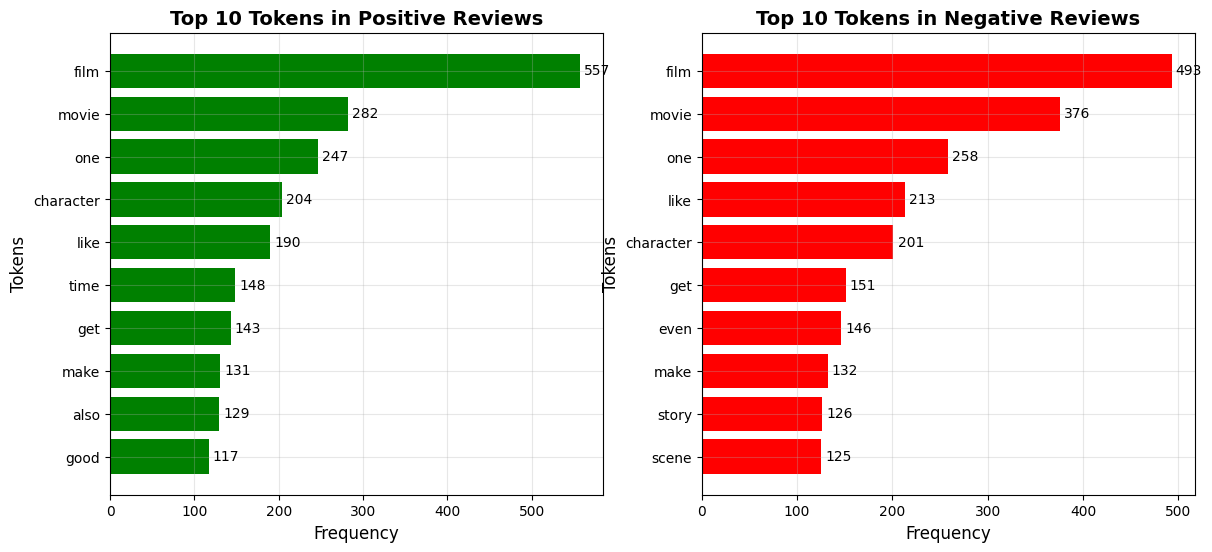

In [73]:
import matplotlib.pyplot as plt

fig,  (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

word_pos = [token for token, _ in pos_top_10_tokens]
counter_pos = [count for _, count in pos_top_10_tokens]

bar1 = ax1.barh(word_pos, counter_pos, color='green')
ax1.set_title('Top 10 Tokens in Positive Reviews', fontsize=14, fontweight='bold')
ax1.set_xlabel('Frequency', fontsize=12)
ax1.set_ylabel('Tokens', fontsize=12)
ax1.bar_label(bar1, labels=counter_pos, padding=3)
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis() 


word_neg = [token for token, _ in neg_top_10_tokens]
counter_neg = [count for _, count in neg_top_10_tokens]

bar2 = ax2.barh(word_neg, counter_neg, color='red')
ax2.set_title('Top 10 Tokens in Negative Reviews', fontsize=14, fontweight='bold')
ax2.set_xlabel('Frequency', fontsize=12)
ax2.set_ylabel('Tokens', fontsize=12)
ax2.bar_label(bar2, labels=counter_neg, padding=3)
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

plt.savefig('movie_review_top_words.png', dpi=300, bbox_inches='tight')
print("Графік 'movie_review_top_words.png' збережено.")

- як змінилася кількість токенів після видалення stop words; - кількість слів зменшилася в два рази, як висновок половина слів взагалі не мала сенсу або була до 3х симболів.

- як лемматизація вплинула на унікальні слова; - зменшилась ще приблизно на 1400 за рахунок об'єднання подібних слів за значенням до максимально простого варіанту.

- які слова найпомітніші в позитивних і негативних відгуках; - в обох категріях є спільні слова, за кількістю дещо відрізняються, але стійко заняли своє місце - film, movies, one.

- чому частотний аналіз ще не є повноцінною sentiment-моделлю. - модель не враховує порядок слів, можливо не зовсім розуміє значення слів. Так як ми відкидаємо stopword, то модель не враховує заперечення. Модель працює на базовомку рівні поділяючи на "чорне і біле" = "positiv & negativ"? не враховуючи контексту.